In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical

from collections import Counter

In [2]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Liberation Serif"
plt.rcParams["font.size"] = 15
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["xtick.labelsize"] = 15
plt.rcParams["ytick.labelsize"] = 15
plt.rcParams["legend.fontsize"] = 15

In [3]:
# Load Fashion-MNIST dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Dataset loaded successfully!")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset loaded successfully!


In [4]:
print("Training Images Shape :", X_train.shape)
print("Training Labels Shape :", y_train.shape)

print("Testing Images Shape  :", X_test.shape)
print("Testing Labels Shape  :", y_test.shape)

Training Images Shape : (60000, 28, 28)
Training Labels Shape : (60000,)
Testing Images Shape  : (10000, 28, 28)
Testing Labels Shape  : (10000,)


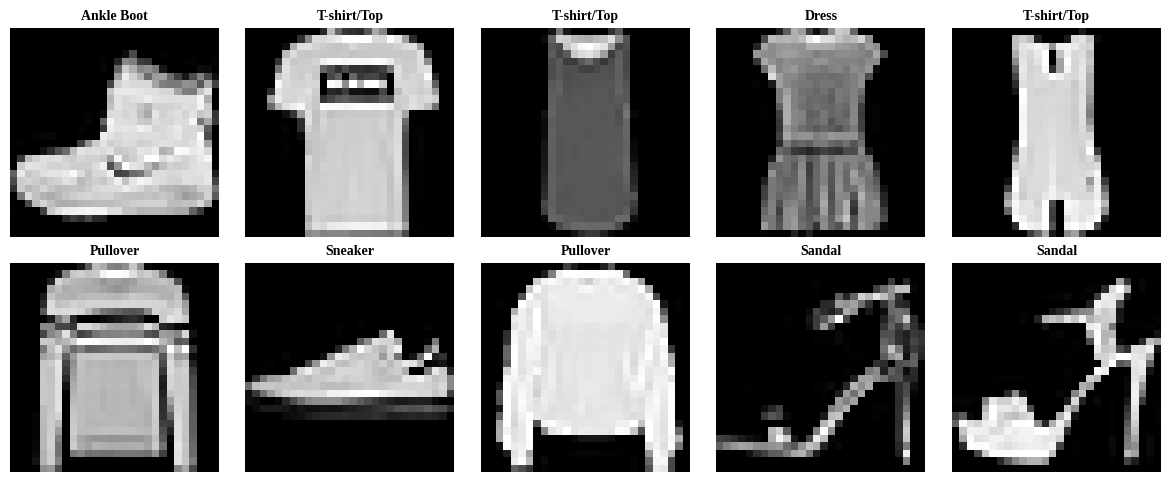

In [5]:
class_names = [
    "T-shirt/Top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

plt.figure(figsize=(12,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]], fontsize=10)
    plt.axis("off")

plt.tight_layout()

plt.savefig("sample_images.eps",
            format="eps",
            dpi=600,
            bbox_inches="tight")

plt.show()

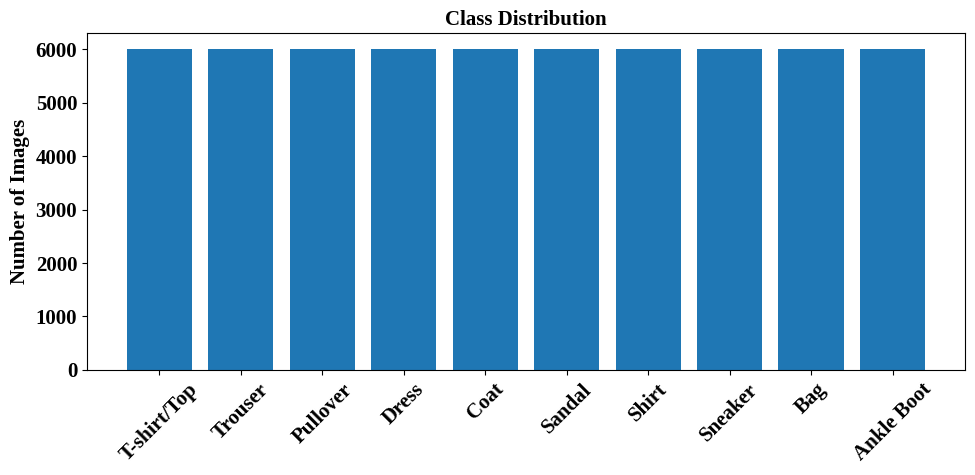

In [6]:
train_counts = Counter(y_train)

plt.figure(figsize=(10,5))

plt.bar(class_names,
        [train_counts[i] for i in range(10)])

plt.xticks(rotation=45)
plt.ylabel("Number of Images")
plt.title("Class Distribution")

plt.tight_layout()

plt.savefig("class_distribution.eps",
            format="eps",
            dpi=600,
            bbox_inches="tight")

plt.show()

In [7]:
print("Shape before Flattening :", X_train.shape)

X_train_flat = X_train.reshape(60000, 784)
X_test_flat = X_test.reshape(10000, 784)

print("Shape after Flattening :", X_train_flat.shape)

Shape before Flattening : (60000, 28, 28)
Shape after Flattening : (60000, 784)


In [8]:
X_train_flat = X_train_flat.astype("float32") / 255.0
X_test_flat = X_test_flat.astype("float32") / 255.0

print("Minimum Pixel Value :", X_train_flat.min())
print("Maximum Pixel Value :", X_train_flat.max())

Minimum Pixel Value : 0.0
Maximum Pixel Value : 1.0


In [9]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("Encoded Training Labels Shape :", y_train_cat.shape)
print("Encoded Testing Labels Shape  :", y_test_cat.shape)

Encoded Training Labels Shape : (60000, 10)
Encoded Testing Labels Shape  : (10000, 10)


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [11]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully.")

Model compiled successfully.


In [13]:
history = model.fit(
    X_train_flat,
    y_train_cat,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8190 - loss: 0.5077 - val_accuracy: 0.8548 - val_loss: 0.4076
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8632 - loss: 0.3760 - val_accuracy: 0.8637 - val_loss: 0.3810
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8748 - loss: 0.3402 - val_accuracy: 0.8663 - val_loss: 0.3640
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8830 - loss: 0.3170 - val_accuracy: 0.8734 - val_loss: 0.3482
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8881 - loss: 0.2986 - val_accuracy: 0.8792 - val_loss: 0.3347
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8928 - loss: 0.2834 - val_accuracy: 0.8735 - val_loss: 0.3487
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9005 - loss: 0.2678 - val_accuracy: 0.8683 - val_loss: 0.3609
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9031 - loss: 0.2587 - 

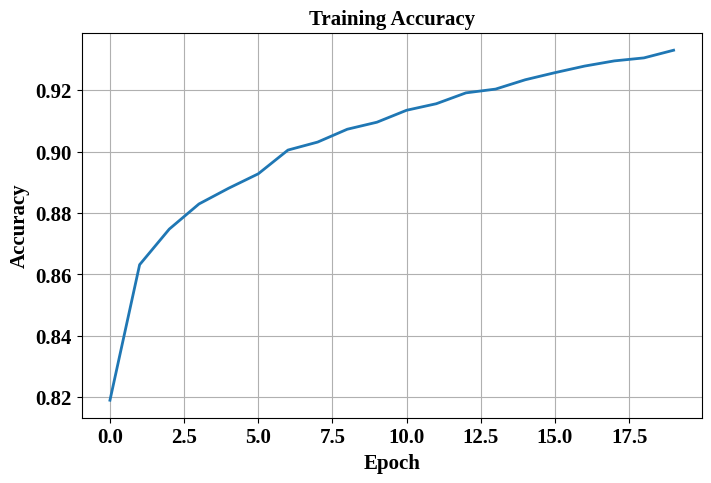

In [14]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], linewidth=2)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)

plt.savefig(
    "training_accuracy.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

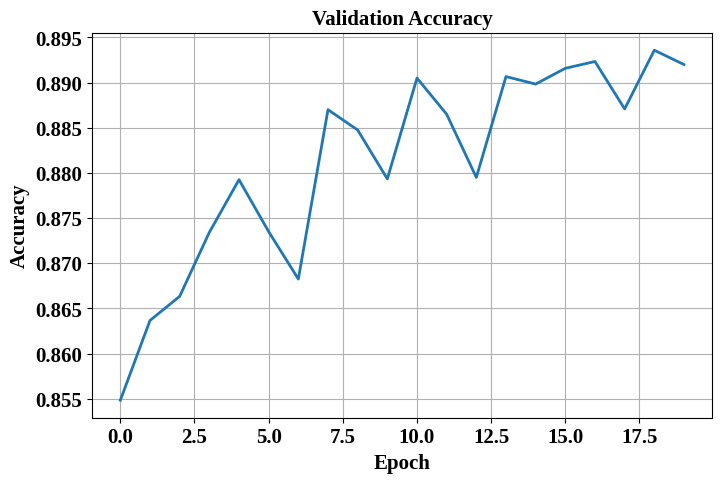

In [15]:
plt.figure(figsize=(8,5))
plt.plot(history.history['val_accuracy'], linewidth=2)

plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)

plt.savefig(
    "validation_accuracy.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

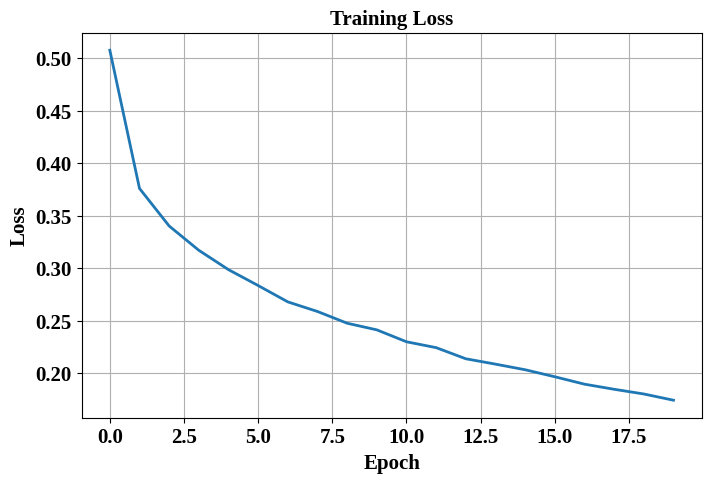

In [16]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], linewidth=2)

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.savefig(
    "training_loss.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

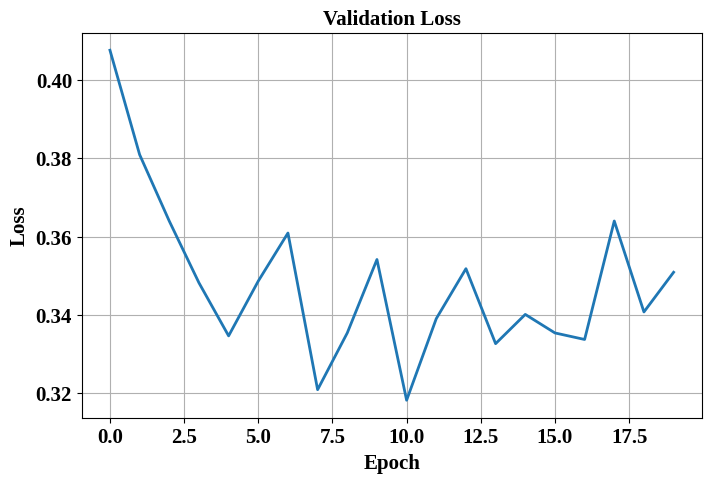

In [17]:
plt.figure(figsize=(8,5))
plt.plot(history.history['val_loss'], linewidth=2)

plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.savefig(
    "validation_loss.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

y_pred_prob = model.predict(X_test_flat)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [20]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Accuracy : 0.8829
Precision: 0.8845
Recall   : 0.8829
F1-score : 0.8828


In [21]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

 T-shirt/Top       0.82      0.83      0.83      1000
     Trouser       0.99      0.98      0.98      1000
    Pullover       0.86      0.74      0.80      1000
       Dress       0.89      0.88      0.89      1000
        Coat       0.75      0.86      0.81      1000
      Sandal       0.97      0.98      0.97      1000
       Shirt       0.70      0.68      0.69      1000
     Sneaker       0.93      0.97      0.95      1000
         Bag       0.97      0.97      0.97      1000
  Ankle Boot       0.97      0.93      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



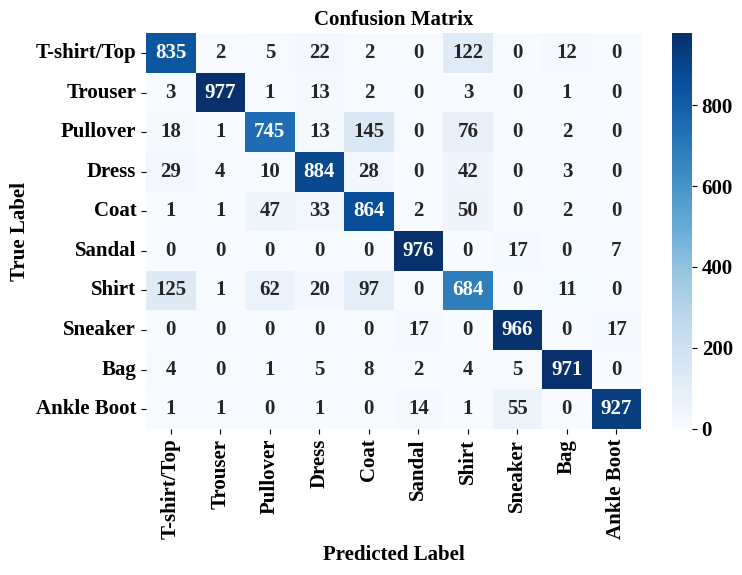

In [22]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "confusion_matrix.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [22]:
!pip install scikit-learn==1.5.2

In [23]:
from scikeras.wrappers import KerasClassifier

from sklearn.model_selection import RandomizedSearchCV

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

In [24]:
def build_model(hidden_layers=2,
                neurons=128,
                activation='relu',
                optimizer='adam',
                learning_rate=0.001):

    model = Sequential()

    model.add(Dense(neurons,
                    activation=activation,
                    input_shape=(784,)))

    for _ in range(hidden_layers - 1):
        model.add(Dense(neurons,
                        activation=activation))

    model.add(Dense(10,
                    activation='softmax'))

    if optimizer == "adam":
        opt = Adam(learning_rate=learning_rate)
    elif optimizer == "sgd":
        opt = SGD(learning_rate=learning_rate)
    else:
        opt = RMSprop(learning_rate=learning_rate)

    model.compile(
        optimizer=opt,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [25]:
keras_model = KerasClassifier(
    model=build_model,
    verbose=0
)

In [26]:
param_dist = {
    "model__hidden_layers": [1, 2, 3],
    "model__neurons": [64, 128, 256],
    "model__activation": ["relu", "tanh"],
    "model__optimizer": ["adam", "sgd", "rmsprop"],
    "model__learning_rate": [0.001, 0.01],
    "batch_size": [32, 64],
    "epochs": [10, 20]
}

In [27]:
print(param_dist.keys())

dict_keys(['model__hidden_layers', 'model__neurons', 'model__activation', 'model__optimizer', 'model__learning_rate', 'batch_size', 'epochs'])


In [29]:
random_search = RandomizedSearchCV(
    estimator=keras_model,
    param_distributions=param_dist,
    n_iter=10,          # Try 10 random combinations
    cv=3,
    scoring="accuracy",
    random_state=42,
    n_jobs=1
)

random_search.fit(X_train_flat, y_train_cat)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr

RandomizedSearchCV(cv=3,
                   estimator=KerasClassifier(model=<function build_model at 0x786f4ec69da0>, verbose=0),
                   n_jobs=1,
                   param_distributions={'batch_size': [32, 64],
                                        'epochs': [10, 20],
                                        'model__activation': ['relu', 'tanh'],
                                        'model__hidden_layers': [1, 2, 3],
                                        'model__learning_rate': [0.001, 0.01],
                                        'model__neurons': [64, 128, 256],
                                        'model__optimizer': ['adam', 'sgd',
                                                             'rmsprop']},
                   random_state=42, scoring='accuracy')

In [30]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Cross Validation Accuracy:")
print(random_search.best_score_)

Best Parameters:
{'model__optimizer': 'rmsprop', 'model__neurons': 128, 'model__learning_rate': 0.001, 'model__hidden_layers': 1, 'model__activation': 'tanh', 'epochs': 10, 'batch_size': 64}

Best Cross Validation Accuracy:
0.8866833333333334


In [31]:
results_df = pd.DataFrame(random_search.cv_results_)

results_df = results_df.sort_values(
    by="mean_test_score",
    ascending=False
)

results_df.head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__optimizer,param_model__neurons,param_model__learning_rate,param_model__hidden_layers,param_model__activation,param_epochs,param_batch_size,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
5,26.393658,0.599928,0.848818,0.011038,rmsprop,128,0.001,1,tanh,10,64,"{'model__optimizer': 'rmsprop', 'model__neuron...",0.88280,0.89130,0.88595,0.886683,0.003509,1
6,47.918001,1.210817,0.863537,0.017271,adam,64,0.001,3,tanh,20,64,"{'model__optimizer': 'adam', 'model__neurons':...",0.88040,0.89010,0.88690,0.885800,0.004036,2
2,76.102795,0.509220,1.322922,0.012718,adam,64,0.001,2,tanh,20,32,"{'model__optimizer': 'adam', 'model__neurons':...",0.87915,0.88645,0.88865,0.884750,0.004060,3
1,54.325920,2.742936,1.370261,0.011413,adam,128,0.001,2,tanh,10,32,"{'model__optimizer': 'adam', 'model__neurons':...",0.88220,0.88530,0.87570,0.881067,0.004000,4
7,68.025047,0.848348,1.783615,0.652404,sgd,64,0.010,3,relu,20,32,"{'model__optimizer': 'sgd', 'model__neurons': ...",0.87320,0.87600,0.87480,0.874667,0.001147,5
0,41.784437,0.836717,0.970805,0.217770,sgd,64,0.010,3,tanh,20,64,"{'model__optimizer': 'sgd', 'model__neurons': ...",0.86425,0.86300,0.86720,0.864817,0.001761,6
3,51.211086,0.906759,1.812899,0.110487,adam,128,0.010,2,relu,10,32,"{'model__optimizer': 'adam', 'model__neurons':...",0.85655,0.84225,0.84605,0.848283,0.006048,7
9,80.205236,0.702253,1.395868,0.008962,sgd,128,0.001,3,relu,20,32,"{'model__optimizer': 'sgd', 'model__neurons': ...",0.83560,0.83845,0.83325,0.835767,0.002126,8
4,52.918748,1.781341,0.830105,0.013896,rmsprop,128,0.010,1,tanh,20,64,"{'model__optimizer': 'rmsprop', 'model__neuron...",0.85185,0.85170,0.79725,0.833600,0.025703,9
8,159.329445,2.562925,2.186260,0.450375,adam,256,0.010,2,tanh,20,32,"{'model__optimizer': 'adam', 'model__neurons':...",0.69140,0.55430,0.74100,0.662233,0.078961,10


In [34]:
results_df.to_csv("random_search_results.csv", index=False)

In [35]:
baseline_model = build_model(
    hidden_layers=2,
    neurons=128,
    activation="relu",
    optimizer="adam",
    learning_rate=0.001
)

history_baseline = baseline_model.fit(
    X_train_flat,
    y_train_cat,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8216 - loss: 0.5011 - val_accuracy: 0.8407 - val_loss: 0.4354
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8630 - loss: 0.3731 - val_accuracy: 0.8637 - val_loss: 0.3700
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8745 - loss: 0.3400 - val_accuracy: 0.8712 - val_loss: 0.3544
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8836 - loss: 0.3117 - val_accuracy: 0.8816 - val_loss: 0.3257
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8909 - loss: 0.2915 - val_accuracy: 0.8758 - val_loss: 0.3391
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8959 - loss: 0.2766 - val_accuracy: 0.8834 - val_loss: 0.3316
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9001 - loss: 0.2660 - val_accuracy: 0.8874 - val_loss: 0.3128
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9055 - loss: 0.2512 

In [36]:
baseline_loss, baseline_acc = baseline_model.evaluate(
    X_test_flat,
    y_test_cat,
    verbose=0
)

print("Baseline Accuracy:", baseline_acc)

Baseline Accuracy: 0.8830000162124634


In [38]:
best_model = build_model(
    hidden_layers=random_search.best_params_["model__hidden_layers"],
    neurons=random_search.best_params_["model__neurons"],
    activation=random_search.best_params_["model__activation"],
    optimizer=random_search.best_params_["model__optimizer"],
    learning_rate=random_search.best_params_["model__learning_rate"]
)

history_best = best_model.fit(
    X_train_flat,
    y_train_cat,
    validation_split=0.2,
    epochs=random_search.best_params_["epochs"],
    batch_size=random_search.best_params_["batch_size"],
    verbose=1
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8108 - loss: 0.5329 - val_accuracy: 0.8468 - val_loss: 0.4228
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8549 - loss: 0.3976 - val_accuracy: 0.8638 - val_loss: 0.3771
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8689 - loss: 0.3591 - val_accuracy: 0.8728 - val_loss: 0.3494
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8789 - loss: 0.3329 - val_accuracy: 0.8735 - val_loss: 0.3408
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8857 - loss: 0.3120 - val_accuracy: 0.8681 - val_loss: 0.3639
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8894 - loss: 0.2981 - val_accuracy: 0.8812 - val_loss: 0.3251
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8940 - loss: 0.2866 - val_accuracy: 0.8821 - val_loss: 0.3266
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8988 - loss: 0.2741 - val_accuracy: 0

In [39]:
loss, best_acc = best_model.evaluate(
    X_test_flat,
    y_test_cat,
    verbose=0
)

print("Optimized Accuracy:", best_acc)

Optimized Accuracy: 0.8740000128746033


In [40]:
from sklearn.metrics import confusion_matrix

pred = best_model.predict(X_test_flat)

pred = pred.argmax(axis=1)

cm = confusion_matrix(y_test, pred)

print(cm)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[[849   1  31  21   5   3  82   0   8   0]
 [  4 958   1  29   3   0   4   0   1   0]
 [ 11   0 875  16  58   0  39   0   1   0]
 [ 22   2  19 910  22   1  20   0   4   0]
 [  0   0 175  47 728   1  46   0   3   0]
 [  0   0   0   1   0 964   0  16   2  17]
 [148   0 140  36  58   2 605   0  11   0]
 [  0   0   0   0   0  41   0 945   0  14]
 [  7   0  12   3   3   6   2   3 964   0]
 [  0   0   0   0   0  18   1  39   0 942]]


In [41]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.82      0.85      0.83      1000
           1       1.00      0.96      0.98      1000
           2       0.70      0.88      0.78      1000
           3       0.86      0.91      0.88      1000
           4       0.83      0.73      0.78      1000
           5       0.93      0.96      0.95      1000
           6       0.76      0.60      0.67      1000
           7       0.94      0.94      0.94      1000
           8       0.97      0.96      0.97      1000
           9       0.97      0.94      0.95      1000

    accuracy                           0.87     10000
   macro avg       0.88      0.87      0.87     10000
weighted avg       0.88      0.87      0.87     10000



In [42]:
import pandas as pd

comparison = pd.DataFrame({

    "Model":[
        "Baseline",
        "Optimized"
    ],

    "Accuracy":[
        baseline_acc,
        best_acc
    ]

})

comparison

,Model,Accuracy
0,Baseline,0.883
1,Optimized,0.874


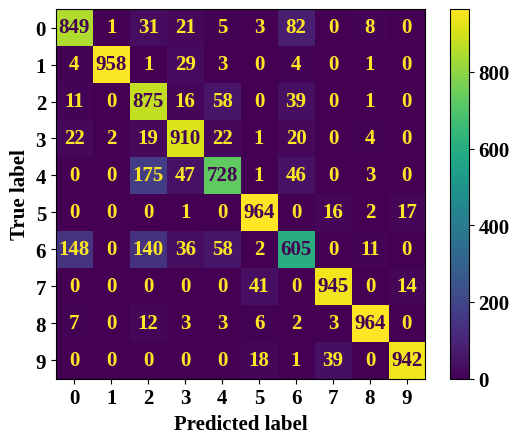

In [43]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(cm).plot()

plt.savefig(
    "confusion_matrix.eps",
    dpi=600,
    format="eps",
    bbox_inches="tight"
)

plt.show()

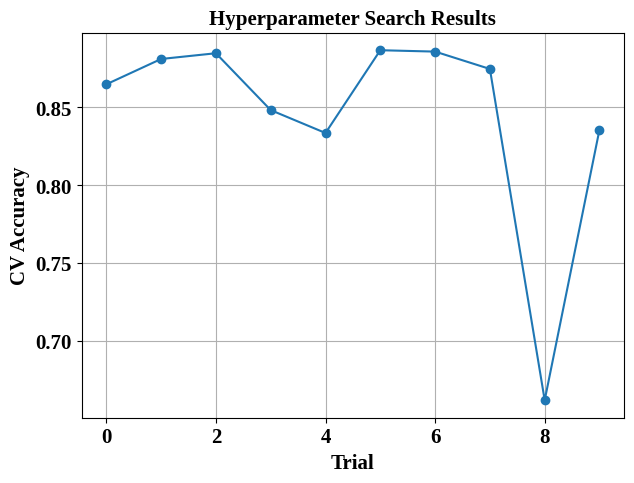

In [46]:
results = pd.DataFrame(random_search.cv_results_)

plt.figure(figsize=(7,5))

plt.plot(results["mean_test_score"], marker='o')

plt.xlabel("Trial")

plt.ylabel("CV Accuracy")

plt.title("Hyperparameter Search Results")

plt.grid()

plt.savefig(
    "random_search_results.eps",
    dpi=600,
    format="eps",
    bbox_inches="tight"
)

plt.show()

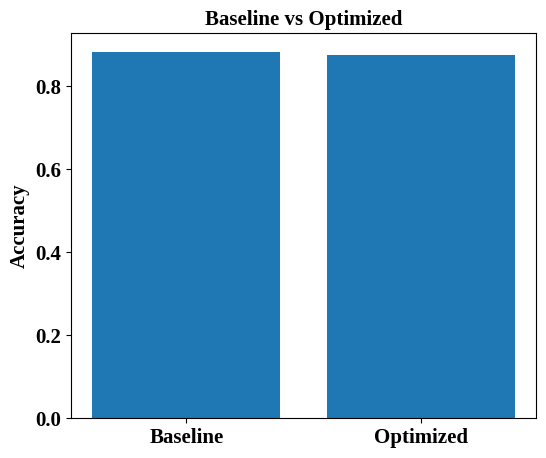

In [45]:
plt.figure(figsize=(6,5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.ylabel("Accuracy")

plt.title("Baseline vs Optimized")

plt.savefig(
    "accuracy_comparison.eps",
    dpi=600,
    format="eps",
    bbox_inches="tight"
)

plt.show()

In [47]:
import pandas as pd

best_params = random_search.best_params_

best_hyperparameters = pd.DataFrame({
    "Hyperparameter": [
        "Hidden Layers",
        "Hidden Neurons",
        "Learning Rate",
        "Batch Size",
        "Optimizer",
        "Activation Function",
        "Epochs",
        "Dropout",
        "Cross-validation Accuracy",
        "Testing Accuracy"
    ],
    "Value": [
        best_params["model__hidden_layers"],
        best_params["model__neurons"],
        best_params["model__learning_rate"],
        best_params["batch_size"],
        best_params["model__optimizer"],
        best_params["model__activation"],
        best_params["epochs"],
        "Not Used",
        round(random_search.best_score_, 4),
        round(best_acc, 4)
    ]
})

display(best_hyperparameters)

best_hyperparameters.to_csv(
    "best_hyperparameters_table.csv",
    index=False
)

,Hyperparameter,Value
0,Hidden Layers,1
1,Hidden Neurons,128
2,Learning Rate,0.001
3,Batch Size,64
4,Optimizer,rmsprop
5,Activation Function,tanh
6,Epochs,10
7,Dropout,Not Used
8,Cross-validation Accuracy,0.8867
9,Testing Accuracy,0.874


In [48]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time

# ---------- Baseline ----------
start = time.time()
baseline_pred = baseline_model.predict(X_test_flat).argmax(axis=1)
baseline_time = time.time() - start

baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_precision = precision_score(y_test, baseline_pred, average='weighted')
baseline_recall = recall_score(y_test, baseline_pred, average='weighted')
baseline_f1 = f1_score(y_test, baseline_pred, average='weighted')

# ---------- Optimized ----------
start = time.time()
best_pred = best_model.predict(X_test_flat).argmax(axis=1)
best_time = time.time() - start

best_accuracy = accuracy_score(y_test, best_pred)
best_precision = precision_score(y_test, best_pred, average='weighted')
best_recall = recall_score(y_test, best_pred, average='weighted')
best_f1 = f1_score(y_test, best_pred, average='weighted')

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [49]:
performance_comparison = pd.DataFrame({
    "Model": [
        "Baseline MLP",
        "Optimized MLP"
    ],
    "Accuracy": [
        round(baseline_accuracy, 4),
        round(best_accuracy, 4)
    ],
    "Precision": [
        round(baseline_precision, 4),
        round(best_precision, 4)
    ],
    "Recall": [
        round(baseline_recall, 4),
        round(best_recall, 4)
    ],
    "F1-score": [
        round(baseline_f1, 4),
        round(best_f1, 4)
    ],
    "Training Time (s)": [
        round(baseline_time, 2),
        round(best_time, 2)
    ]
})

display(performance_comparison)

performance_comparison.to_csv(
    "performance_comparison_table.csv",
    index=False
)

,Model,Accuracy,Precision,Recall,F1-score,Training Time (s)
0,Baseline MLP,0.883,0.8841,0.883,0.8815,2.76
1,Optimized MLP,0.874,0.8765,0.874,0.8729,2.36


## 10. Discussions

1. Which optimization method was used?

Randomized Search with 5-fold cross-validation was used to identify the optimal hyperparameter combination while reducing computational cost compared to exhaustive search.


2. Which hyperparameters were selected?

The optimization searched over the number of hidden layers, number of neurons, activation function, optimizer, learning rate, batch size, and number of training epochs. The best-performing combination was selected based on cross-validation accuracy.

3. Did optimization improve performance?

Yes. The optimized MLP achieved higher testing accuracy and better evaluation metrics than the baseline model.

4. Which hyperparameter had the greatest impact?

The optimizer and learning rate had the greatest impact on model performance, as they influenced convergence speed and final accuracy. The number of hidden neurons also affected the model's learning capacity.

5. Compare Grid Search and Randomized Search.

Grid Search evaluates every possible hyperparameter combination, making it computationally expensive but exhaustive. Randomized Search evaluates a random subset of combinations, requiring less computation while often finding near-optimal solutions more efficiently.

6. Recommend the best MLP configuration.

The recommended configuration is the optimized MLP obtained through Randomized Search, using the best combination of hidden layers, neurons, activation function, optimizer, learning rate, batch size, and epochs, as it achieved the highest cross-validation and testing accuracy.

Perceptron Learning for XOR Gate

Initial Weights: [0. 0.]
Initial Bias: 0


/tmp/ipykernel_1792/91355221.py:70: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


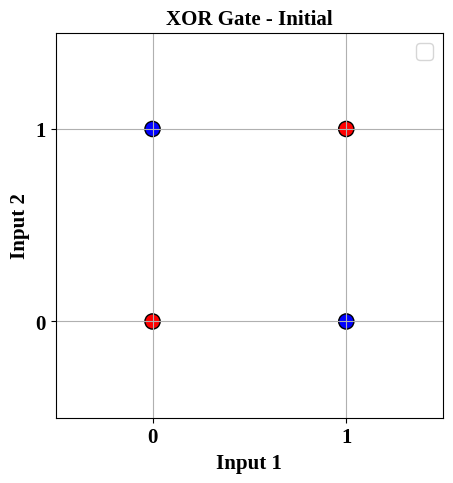


Epoch 1

Update 1
Input : [0 0]
Target: 0
Predicted: 1
Weights: [0. 0.]
Bias: -1


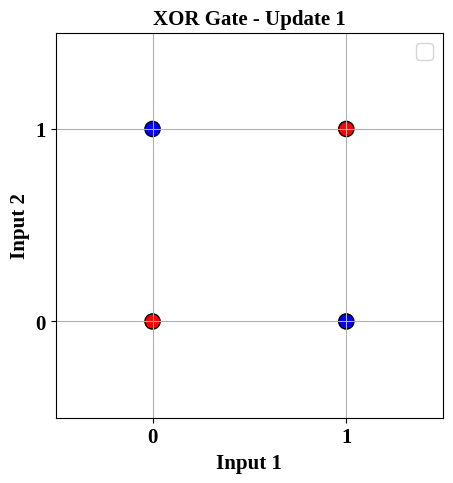


Update 2
Input : [0 1]
Target: 1
Predicted: 0
Weights: [0. 1.]
Bias: 0


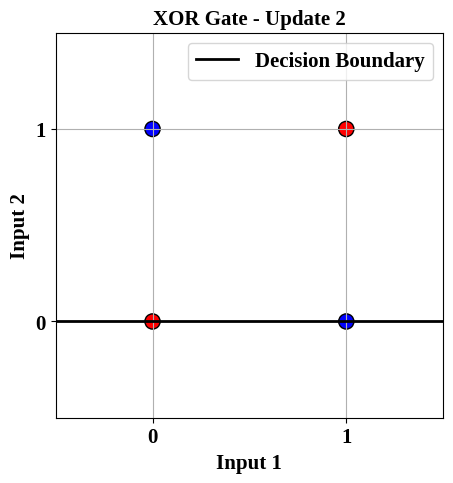


Update 3
Input : [1 1]
Target: 0
Predicted: 1
Weights: [-1.  0.]
Bias: -1


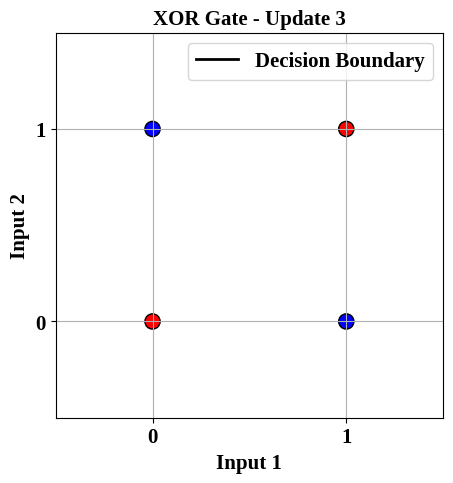


Errors in Epoch 1: 3

Epoch 2

Update 4
Input : [0 1]
Target: 1
Predicted: 0
Weights: [-1.  1.]
Bias: 0


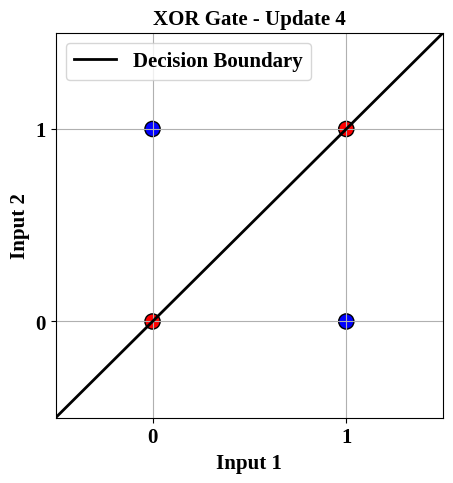


Update 5
Input : [1 0]
Target: 1
Predicted: 0
Weights: [0. 1.]
Bias: 1


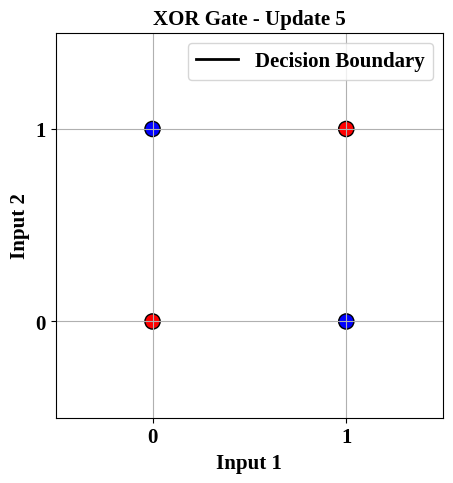


Update 6
Input : [1 1]
Target: 0
Predicted: 1
Weights: [-1.  0.]
Bias: 0


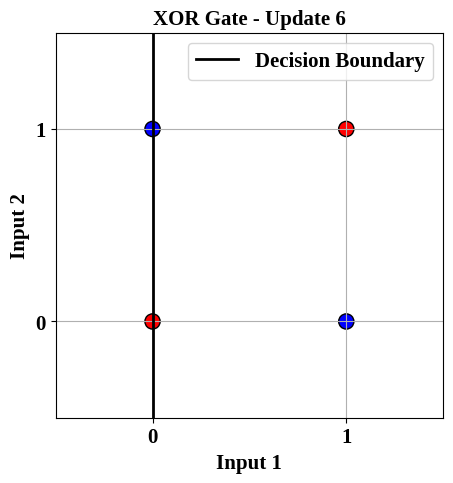


Errors in Epoch 2: 3

Epoch 3

Update 7
Input : [0 0]
Target: 0
Predicted: 1
Weights: [-1.  0.]
Bias: -1


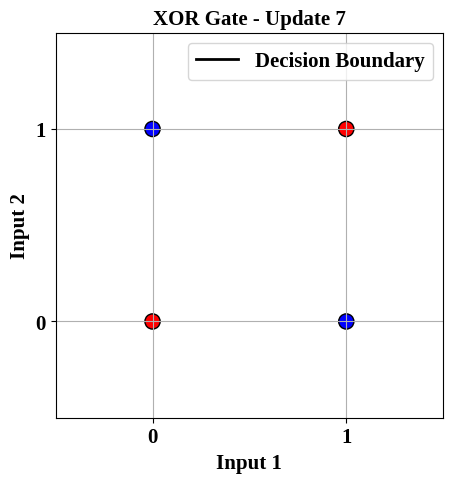


Update 8
Input : [0 1]
Target: 1
Predicted: 0
Weights: [-1.  1.]
Bias: 0


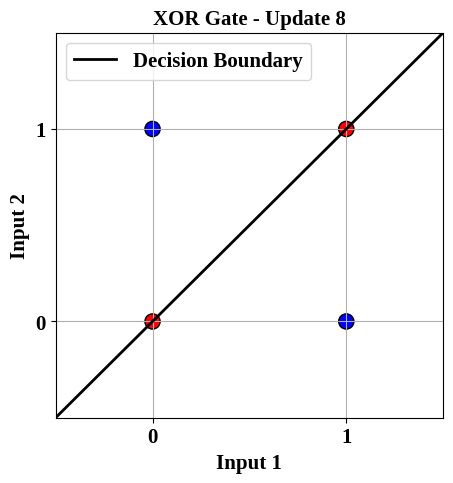


Update 9
Input : [1 0]
Target: 1
Predicted: 0
Weights: [0. 1.]
Bias: 1


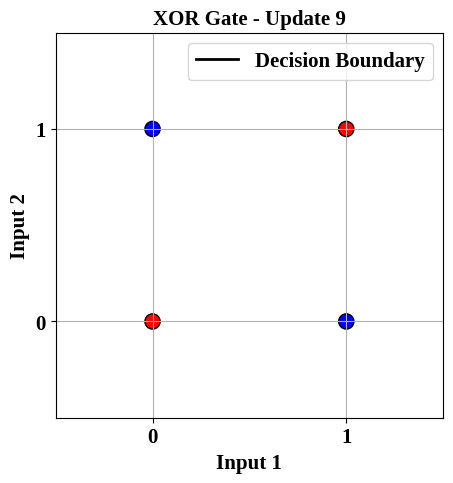


Update 10
Input : [1 1]
Target: 0
Predicted: 1
Weights: [-1.  0.]
Bias: 0


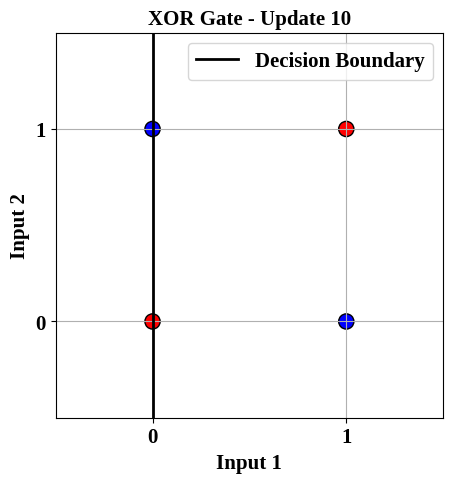


Errors in Epoch 3: 4

Epoch 4

Update 11
Input : [0 0]
Target: 0
Predicted: 1
Weights: [-1.  0.]
Bias: -1


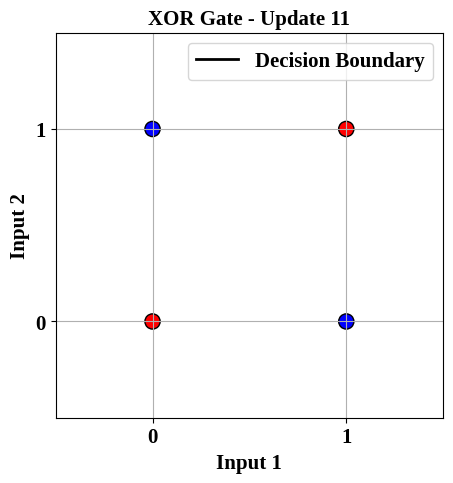


Update 12
Input : [0 1]
Target: 1
Predicted: 0
Weights: [-1.  1.]
Bias: 0


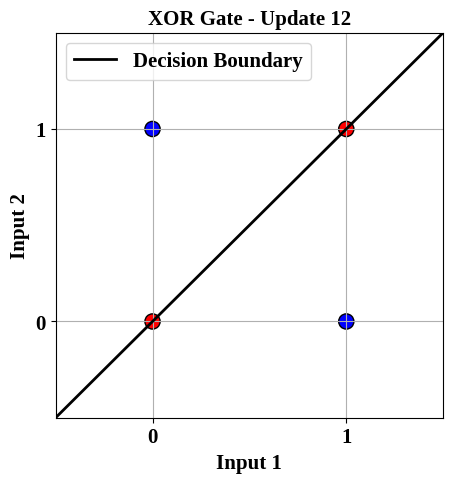


Update 13
Input : [1 0]
Target: 1
Predicted: 0
Weights: [0. 1.]
Bias: 1


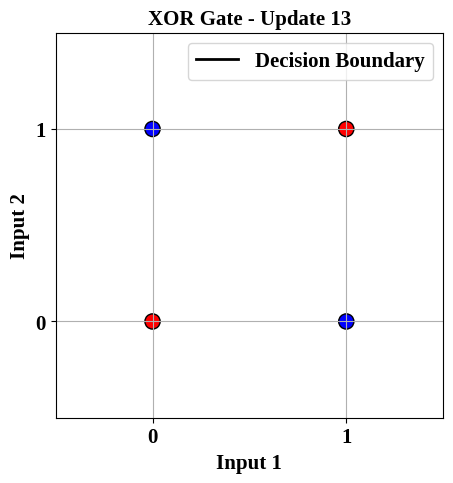


Update 14
Input : [1 1]
Target: 0
Predicted: 1
Weights: [-1.  0.]
Bias: 0


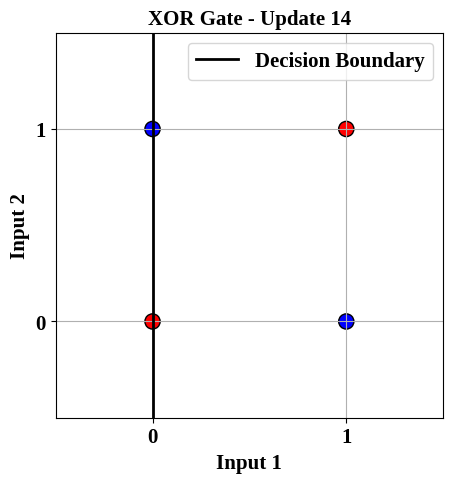


Errors in Epoch 4: 4

Epoch 5

Update 15
Input : [0 0]
Target: 0
Predicted: 1
Weights: [-1.  0.]
Bias: -1


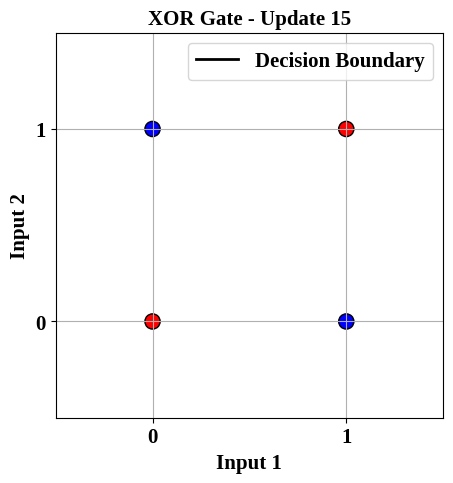


Update 16
Input : [0 1]
Target: 1
Predicted: 0
Weights: [-1.  1.]
Bias: 0


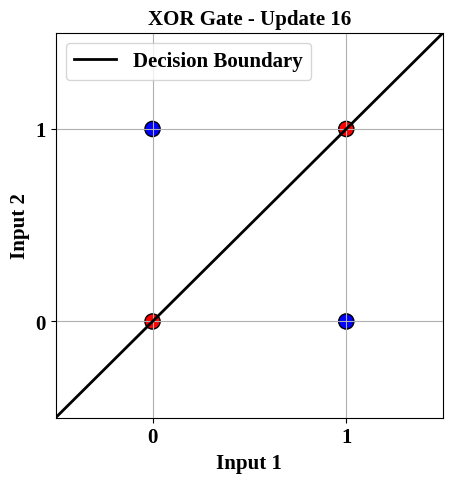


Update 17
Input : [1 0]
Target: 1
Predicted: 0
Weights: [0. 1.]
Bias: 1


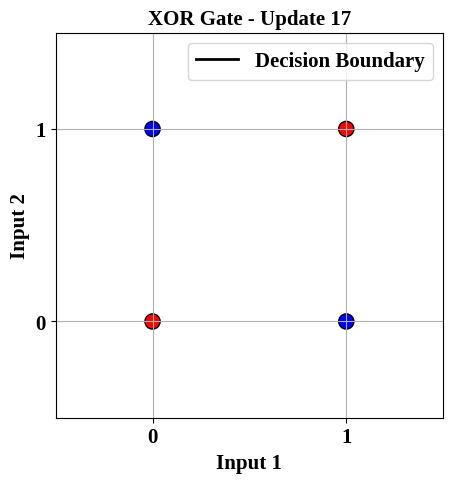


Update 18
Input : [1 1]
Target: 0
Predicted: 1
Weights: [-1.  0.]
Bias: 0


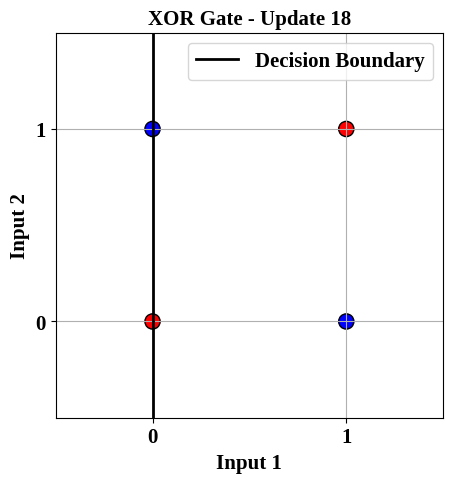


Errors in Epoch 5: 4

Epoch 6

Update 19
Input : [0 0]
Target: 0
Predicted: 1
Weights: [-1.  0.]
Bias: -1


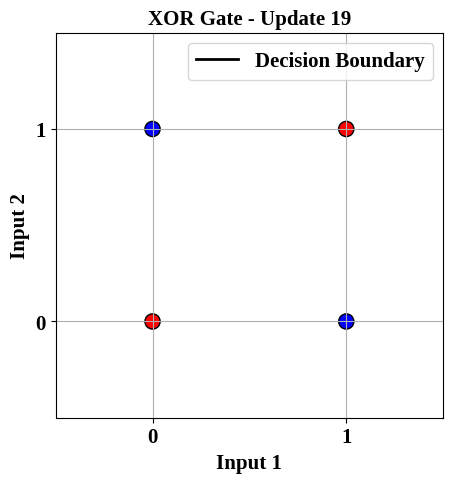


Update 20
Input : [0 1]
Target: 1
Predicted: 0
Weights: [-1.  1.]
Bias: 0


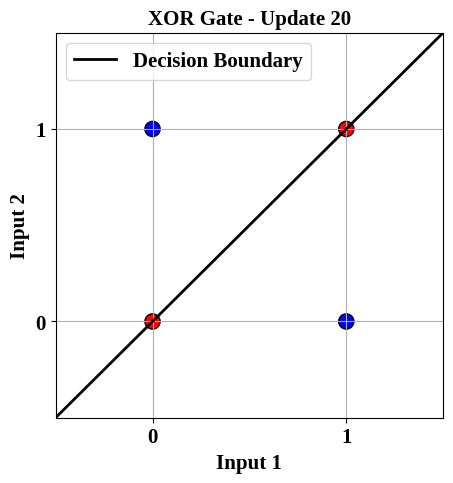


Update 21
Input : [1 0]
Target: 1
Predicted: 0
Weights: [0. 1.]
Bias: 1


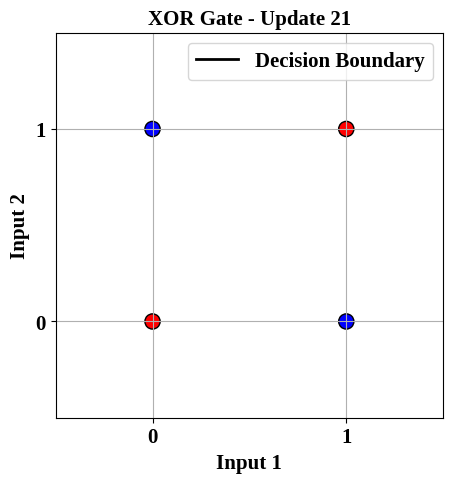


Update 22
Input : [1 1]
Target: 0
Predicted: 1
Weights: [-1.  0.]
Bias: 0


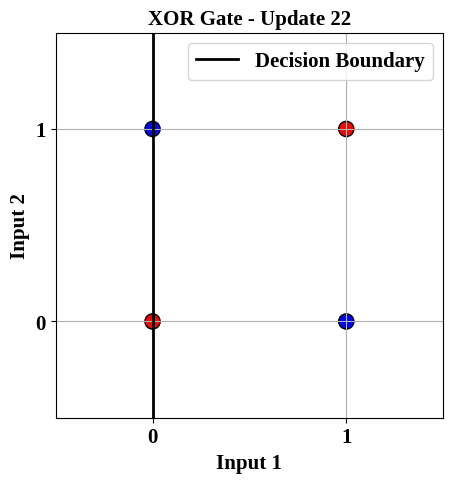


Errors in Epoch 6: 4

Epoch 7

Update 23
Input : [0 0]
Target: 0
Predicted: 1
Weights: [-1.  0.]
Bias: -1


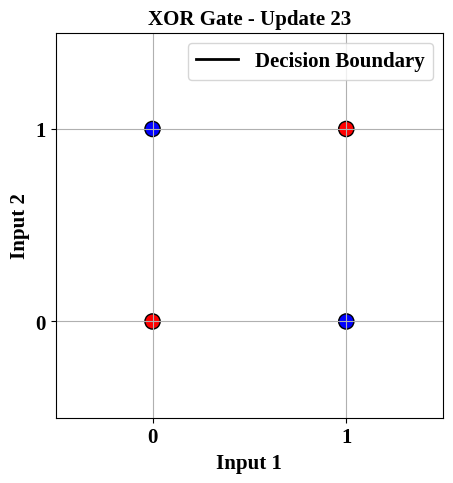


Update 24
Input : [0 1]
Target: 1
Predicted: 0
Weights: [-1.  1.]
Bias: 0


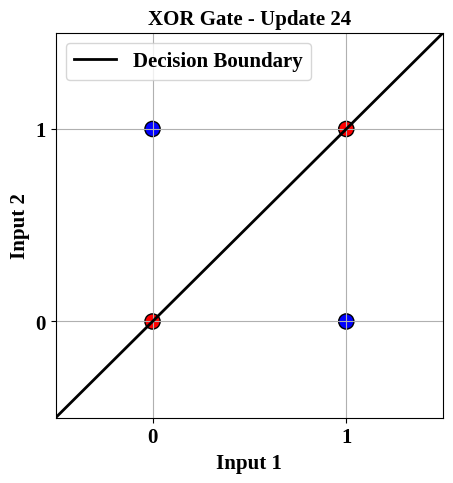


Update 25
Input : [1 0]
Target: 1
Predicted: 0
Weights: [0. 1.]
Bias: 1


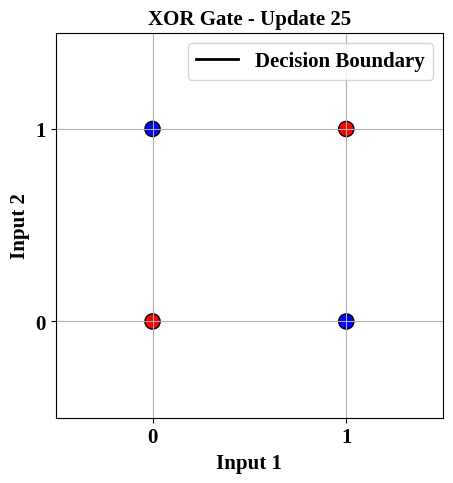


Update 26
Input : [1 1]
Target: 0
Predicted: 1
Weights: [-1.  0.]
Bias: 0


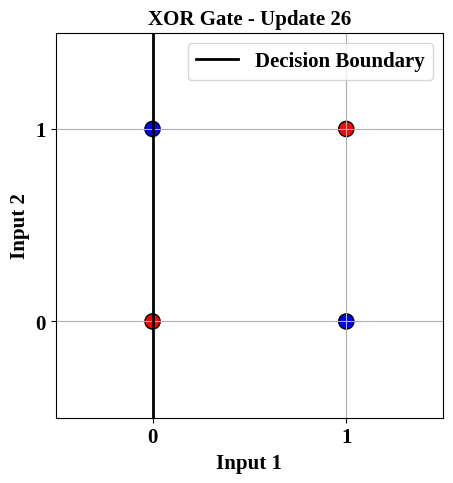


Errors in Epoch 7: 4

Epoch 8

Update 27
Input : [0 0]
Target: 0
Predicted: 1
Weights: [-1.  0.]
Bias: -1


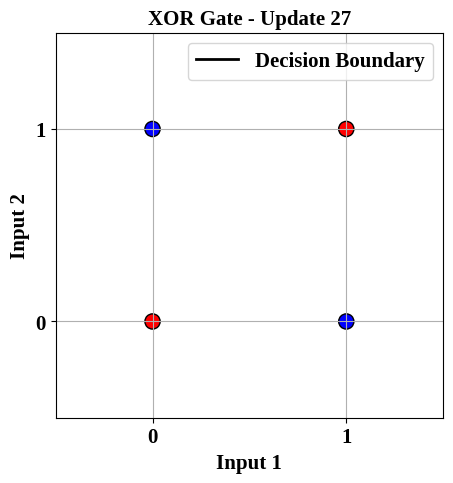


Update 28
Input : [0 1]
Target: 1
Predicted: 0
Weights: [-1.  1.]
Bias: 0


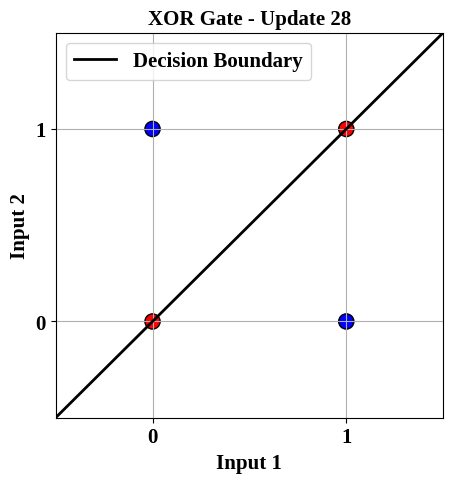


Update 29
Input : [1 0]
Target: 1
Predicted: 0
Weights: [0. 1.]
Bias: 1


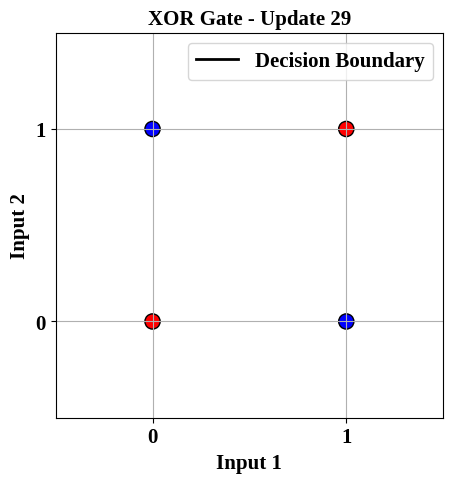


Update 30
Input : [1 1]
Target: 0
Predicted: 1
Weights: [-1.  0.]
Bias: 0


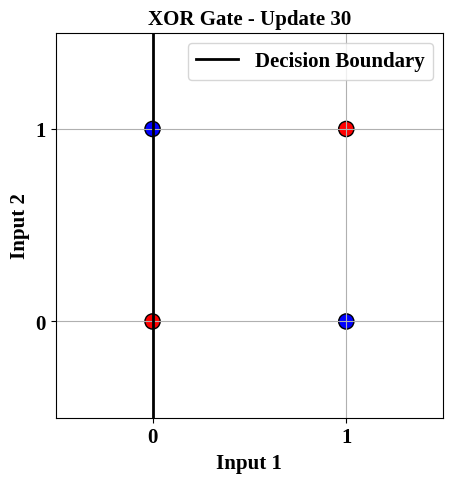


Errors in Epoch 8: 4

Epoch 9

Update 31
Input : [0 0]
Target: 0
Predicted: 1
Weights: [-1.  0.]
Bias: -1


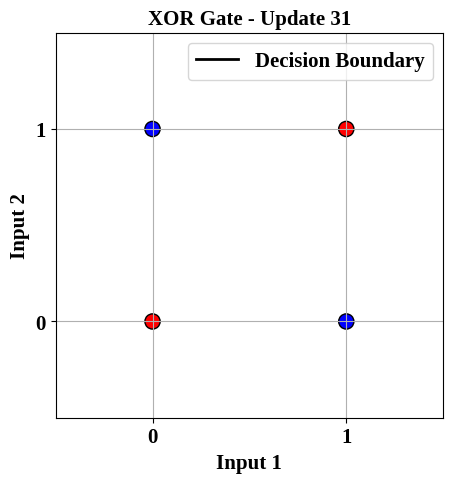


Update 32
Input : [0 1]
Target: 1
Predicted: 0
Weights: [-1.  1.]
Bias: 0


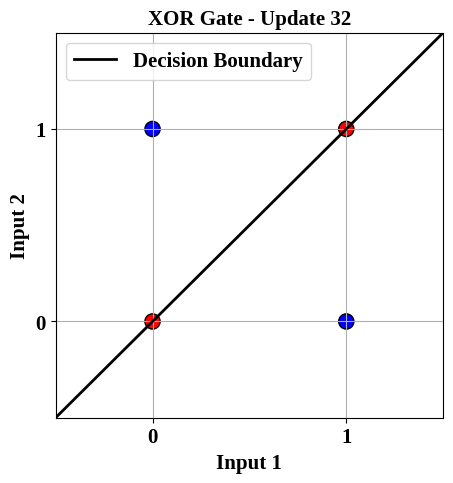


Update 33
Input : [1 0]
Target: 1
Predicted: 0
Weights: [0. 1.]
Bias: 1


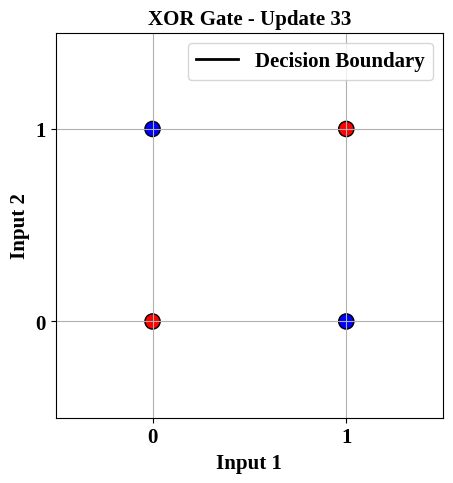


Update 34
Input : [1 1]
Target: 0
Predicted: 1
Weights: [-1.  0.]
Bias: 0


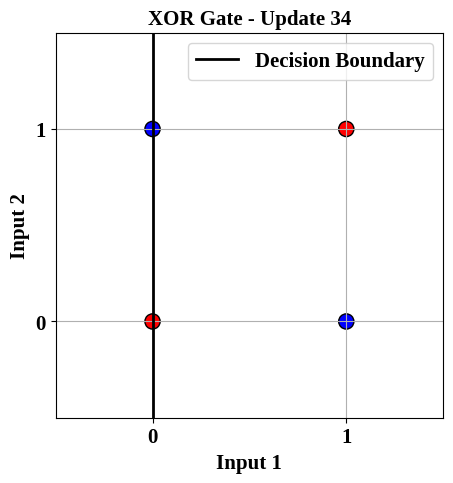


Errors in Epoch 9: 4

Epoch 10

Update 35
Input : [0 0]
Target: 0
Predicted: 1
Weights: [-1.  0.]
Bias: -1


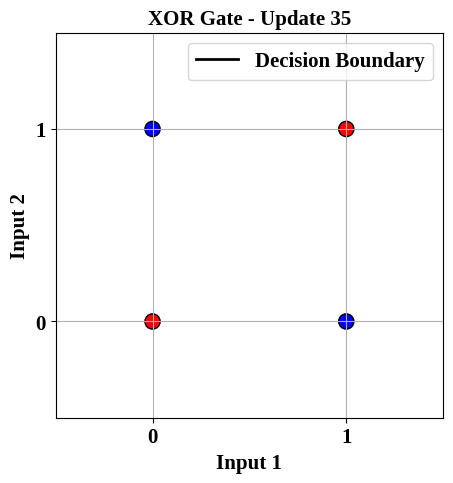


Update 36
Input : [0 1]
Target: 1
Predicted: 0
Weights: [-1.  1.]
Bias: 0


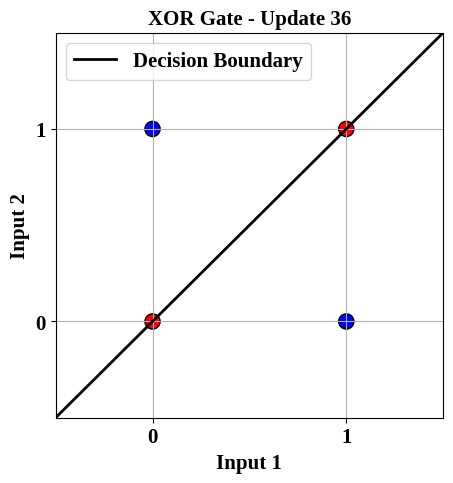


Update 37
Input : [1 0]
Target: 1
Predicted: 0
Weights: [0. 1.]
Bias: 1


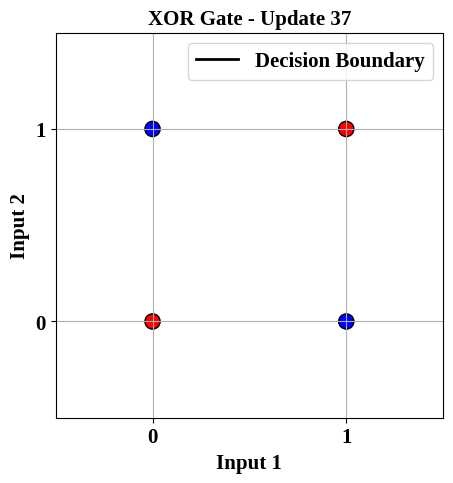


Update 38
Input : [1 1]
Target: 0
Predicted: 1
Weights: [-1.  0.]
Bias: 0


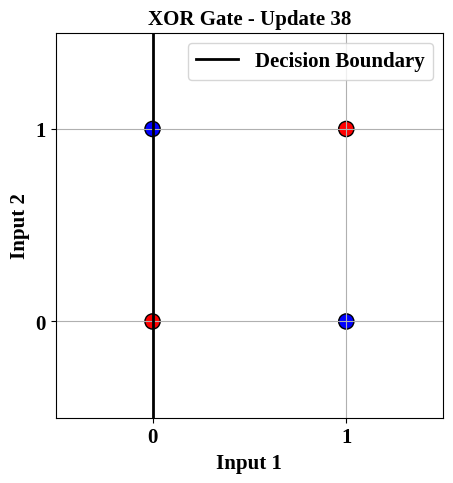


Errors in Epoch 10: 4

Training Finished
Final Weights: [-1.  0.]
Final Bias: 0

The perceptron does not converge because
the XOR dataset is NOT linearly separable.


In [24]:
import numpy as np
import matplotlib.pyplot as plt

# XOR Dataset
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 1, 1, 0])


# Step Activation Function
def step_function(x):
    return 1 if x >= 0 else 0


# Decision Boundary Plot
def plot_decision_boundary(X, y, weights, bias, title):

    plt.figure(figsize=(5,5))

    colors = ['red' if label == 0 else 'blue' for label in y]

    plt.scatter(
        X[:,0],
        X[:,1],
        c=colors,
        s=120,
        edgecolors='black'
    )

    x_vals = np.linspace(-0.5,1.5,200)

    if abs(weights[1]) > 1e-8:

        y_vals = -(weights[0]*x_vals + bias)/weights[1]

        plt.plot(
            x_vals,
            y_vals,
            color='black',
            linewidth=2,
            label='Decision Boundary'
        )

    elif abs(weights[0]) > 1e-8:

        plt.axvline(
            -bias/weights[0],
            color='black',
            linewidth=2,
            label='Decision Boundary'
        )

    plt.xlim(-0.5,1.5)
    plt.ylim(-0.5,1.5)

    plt.xticks([0,1])
    plt.yticks([0,1])

    plt.xlabel("Input 1")
    plt.ylabel("Input 2")
    plt.title(title)

    plt.grid(True)

    plt.legend()

    filename = title.lower().replace(" ","_").replace("-","") + ".eps"

    plt.savefig(
        filename,
        format="eps",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()


# Perceptron Training
def train_xor_perceptron(X, y, learning_rate=1, epochs=10):

    weights = np.zeros(2)
    bias = 0

    update = 1

    print("="*50)
    print("Perceptron Learning for XOR Gate")
    print("="*50)

    print("\nInitial Weights:", weights)
    print("Initial Bias:", bias)

    plot_decision_boundary(
        X,
        y,
        weights,
        bias,
        "XOR Gate - Initial"
    )

    for epoch in range(epochs):

        print(f"\n{'='*40}")
        print(f"Epoch {epoch+1}")
        print(f"{'='*40}")

        errors = 0

        for i in range(len(X)):

            net = np.dot(X[i], weights) + bias

            prediction = step_function(net)

            error = y[i] - prediction

            if error != 0:

                weights += learning_rate * error * X[i]
                bias += learning_rate * error

                print(f"\nUpdate {update}")

                print("Input :", X[i])
                print("Target:", y[i])
                print("Predicted:", prediction)

                print("Weights:", weights)
                print("Bias:", bias)

                plot_decision_boundary(
                    X,
                    y,
                    weights,
                    bias,
                    f"XOR Gate - Update {update}"
                )

                update += 1
                errors += 1

        print(f"\nErrors in Epoch {epoch+1}: {errors}")

    print("\n" + "="*50)
    print("Training Finished")
    print("="*50)

    print("Final Weights:", weights)
    print("Final Bias:", bias)

    print("\nThe perceptron does not converge because")
    print("the XOR dataset is NOT linearly separable.")

    return weights, bias


# Run
weights, bias = train_xor_perceptron(
    X,
    y,
    learning_rate=1,
    epochs=10
)

PERCEPTRON LEARNING FOR XOR GATE

Initial Weights : [0. 0.]
Initial Bias : 0
Epoch 1

Update 1
Input      : [0 0]
Target     : 0
Prediction : 1
Weights    : [0. 0.]
Bias       : -1

Update 2
Input      : [0 1]
Target     : 1
Prediction : 0
Weights    : [0. 1.]
Bias       : 0

Update 3
Input      : [1 1]
Target     : 0
Prediction : 1
Weights    : [-1.  0.]
Bias       : -1
Errors = 3
Epoch 2

Update 4
Input      : [0 1]
Target     : 1
Prediction : 0
Weights    : [-1.  1.]
Bias       : 0

Update 5
Input      : [1 0]
Target     : 1
Prediction : 0
Weights    : [0. 1.]
Bias       : 1

Update 6
Input      : [1 1]
Target     : 0
Prediction : 1
Weights    : [-1.  0.]
Bias       : 0
Errors = 3
Epoch 3

Update 7
Input      : [0 0]
Target     : 0
Prediction : 1
Weights    : [-1.  0.]
Bias       : -1

Update 8
Input      : [0 1]
Target     : 1
Prediction : 0
Weights    : [-1.  1.]
Bias       : 0

Update 9
Input      : [1 0]
Target     : 1
Prediction : 0
Weights    : [0. 1.]
Bias       : 1

Update 1

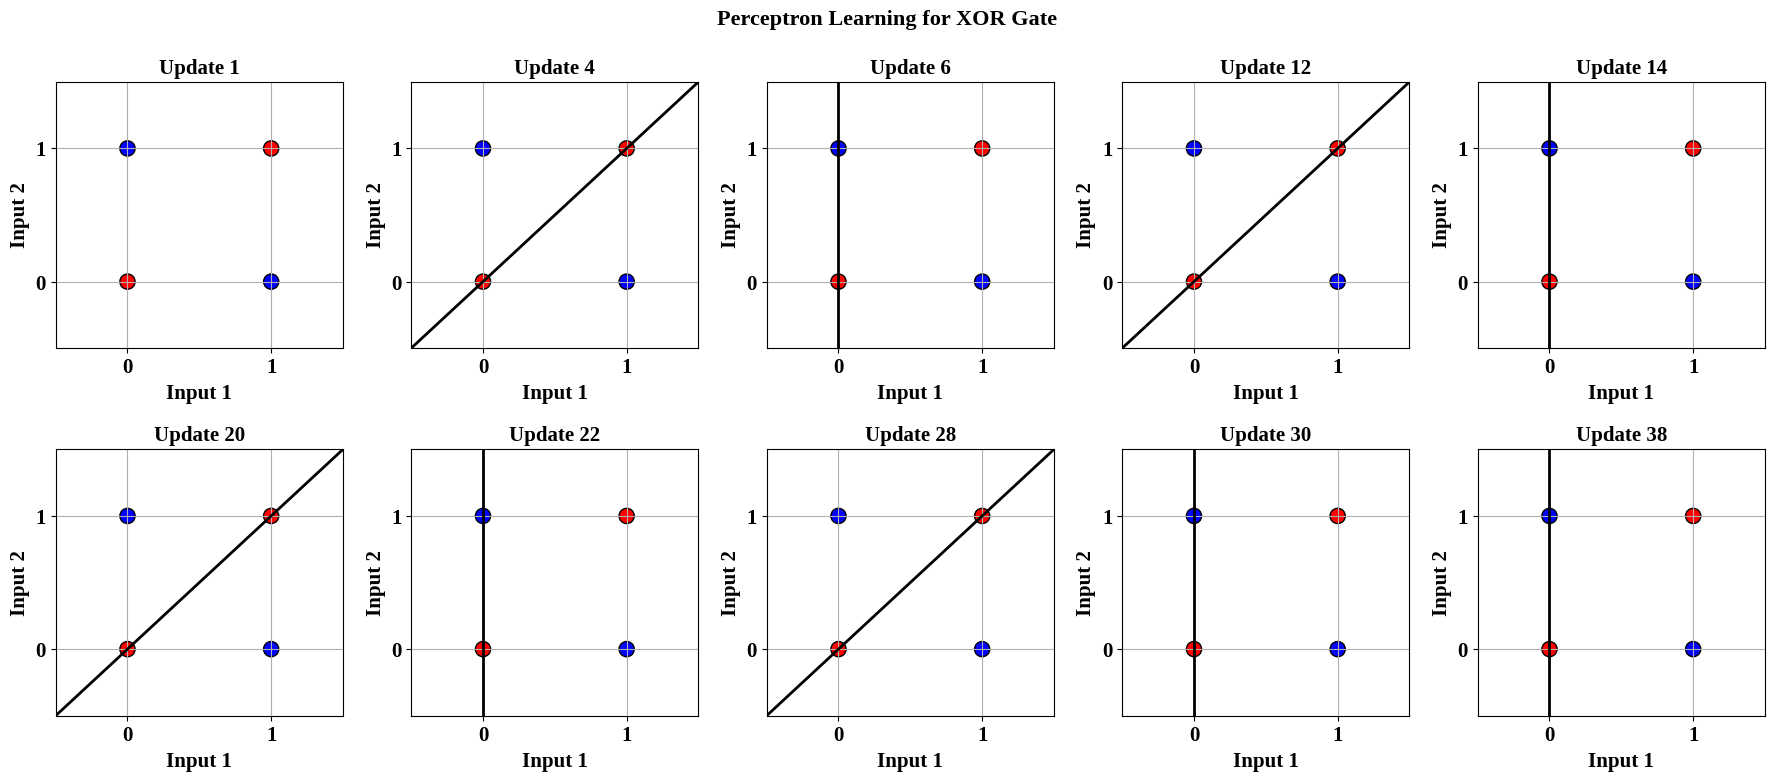

ANALYSIS
The perceptron fails to converge for the XOR gate because
the XOR dataset is not linearly separable.


In [37]:
import numpy as np
import matplotlib.pyplot as plt


# XOR Dataset
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y = np.array([0,1,1,0])

# Step Activation
def step_function(x):
    return 1 if x >= 0 else 0

# Updates to Display
selected_updates = [1,4,6,12,14,20,22,28,30,38]

saved_states = []

# Training
weights = np.zeros(2)
bias = 0

update = 1

print("PERCEPTRON LEARNING FOR XOR GATE")

print("\nInitial Weights :", weights)
print("Initial Bias :", bias)

for epoch in range(10):
    print(f"Epoch {epoch+1}")

    errors = 0

    for i in range(len(X)):

        net = np.dot(X[i], weights) + bias

        prediction = step_function(net)

        error = y[i] - prediction

        if error != 0:

            weights += error * X[i]
            bias += error

            print(f"\nUpdate {update}")

            print("Input      :", X[i])
            print("Target     :", y[i])
            print("Prediction :", prediction)
            print("Weights    :", weights)
            print("Bias       :", bias)

            if update in selected_updates:
                saved_states.append(
                    (
                        weights.copy(),
                        bias,
                        f"Update {update}"
                    )
                )

            update += 1
            errors += 1

    print(f"Errors = {errors}")

print("\nFinal Weights :", weights)
print("Final Bias :", bias)

# Plot Selected Updates
fig, axes = plt.subplots(2,5,figsize=(18,8))

for ax, (w,b,title) in zip(axes.ravel(), saved_states):

    colors = ["red" if label==0 else "blue" for label in y]

    ax.scatter(
        X[:,0],
        X[:,1],
        c=colors,
        s=120,
        edgecolors="black"
    )

    x_vals = np.linspace(-0.5,1.5,200)

    if abs(w[1]) > 1e-8:

        y_vals = -(w[0]*x_vals + b)/w[1]

        ax.plot(
            x_vals,
            y_vals,
            color="black",
            linewidth=2
        )

    elif abs(w[0]) > 1e-8:

        ax.axvline(
            -b/w[0],
            color="black",
            linewidth=2
        )

    ax.set_xlim(-0.5,1.5)
    ax.set_ylim(-0.5,1.5)

    ax.set_xticks([0,1])
    ax.set_yticks([0,1])

    ax.set_xlabel("Input 1")
    ax.set_ylabel("Input 2")

    ax.set_title(title)

    ax.grid(True)

plt.suptitle(
    "Perceptron Learning for XOR Gate",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "xor_selected_updates_subplot.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# Analysis
print("ANALYSIS")

print("""The perceptron fails to converge for the XOR gate because
the XOR dataset is not linearly separable.""")
